ARTI308 - Machine Learning

# Linear Regression

Your neighbor is a real estate agent and wants some help predicting housing prices for regions in the USA. It would be great if you could somehow create a model for her that allows her to put in a few features of a house and returns back an estimate of what the house would sell for.

She has asked you if you could help her out with your new data science skills. You say yes, and decide that Linear Regression might be a good path to solve this problem!

Your neighbor then gives you some information about a bunch of houses in regions of the United States,it is all in the data set: USA_Housing.csv.

The data contains the following columns:

* 'Avg. Area Income': Avg. Income of residents of the city house is located in.
* 'Avg. Area House Age': Avg Age of Houses in same city
* 'Avg. Area Number of Rooms': Avg Number of Rooms for Houses in same city
* 'Avg. Area Number of Bedrooms': Avg Number of Bedrooms for Houses in same city
* 'Area Population': Population of city house is located in
* 'Price': Price that the house sold at
* 'Address': Address for the house

**Let's get started!**
## Check out the data
We've been able to get some data from your neighbor for housing prices as a csv set, let's get our environment ready with the libraries we'll need and then import the data!
### Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Check out the Data

In [9]:
USAhousing = pd.read_csv('USA_Housing.csv')

In [10]:
USAhousing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\r\nLaurabury, NE 37..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\r\nLake Kathleen, ..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\r\nDanieltown, WI 064..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\r\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\r\nFPO AE 09386


In [11]:
USAhousing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [12]:
USAhousing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [13]:
USAhousing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

# EDA

Let's create some simple plots to check out the data!

In [14]:
sns.pairplot(USAhousing)

In [15]:
#sns.distplot(USAhousing['Price'])
sns.histplot(USAhousing['Price'])

<Axes: xlabel='Price', ylabel='Count'>

In [16]:
#sns.heatmap(USAhousing.corr()) this function produced 
sns.heatmap(USAhousing.select_dtypes(include='number').corr())

<Axes: >

## Training a Linear Regression Model

Let's now begin to train out regression model! We will need to first split up our data into an X array that contains the features to train on, and a y array with the target variable, in this case the Price column. We will toss out the Address column because it only has text info that the linear regression model can't use.

### X and y arrays

In [17]:
X = USAhousing[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = USAhousing['Price']

## Train Test Split

Now let's split the data into a training set and a testing set. We will train out model on the training set and then use the test set to evaluate the model.

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## Creating and Training the Model

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lm = LinearRegression()

In [22]:
lm.fit(X_train,y_train)

LinearRegression()

## Model Evaluation

Let's evaluate the model by checking out it's coefficients and how we can interpret them.

In [23]:
# print the intercept
print(lm.intercept_)

-2640159.79685267


In [24]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


Interpreting the coefficients:

- Holding all other features fixed, a 1 unit increase in **Avg. Area Income** is associated with an **increase of \$21.52 **.
- Holding all other features fixed, a 1 unit increase in **Avg. Area House Age** is associated with an **increase of \$164883.28 **.
- Holding all other features fixed, a 1 unit increase in **Avg. Area Number of Rooms** is associated with an **increase of \$122368.67 **.
- Holding all other features fixed, a 1 unit increase in **Avg. Area Number of Bedrooms** is associated with an **increase of \$2233.80 **.
- Holding all other features fixed, a 1 unit increase in **Area Population** is associated with an **increase of \$15.15 **.

Does this make sense? Probably not because I made up this data. If you want real data to repeat this sort of analysis, check out the [boston dataset](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html):



    from sklearn.datasets import load_boston
    boston = load_boston()
    print(boston.DESCR)
    boston_df = boston.data

## Predictions from our Model

Let's grab predictions off our test set and see how well it did!

In [25]:
predictions = lm.predict(X_test)

In [26]:
plt.scatter(y_test,predictions)

**Residual Histogram**

In [27]:
sns.histplot((y_test-predictions),bins=50);

## Regression Evaluation Metrics


Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [28]:
from sklearn import metrics

In [29]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions))) 

MAE: 82288.22251914942
MSE: 10460958907.208948
RMSE: 102278.82922290883


This was your first real Machine Learning Project! Congrats on helping your neighbor out!

### Task:
In this task, you will apply what you have learned in this lab on a new dataset.

We will work with the Ecommerce Customers dataset (you will find it on Blackboard)

1. Load the dataset into a DataFrame
2. Explore the data (head, info, describe)
3. Perform basic data cleaning if needed
4. Apply feature engineering (if applicable)
5. Prepare the data for modeling
6. Train a model (use the same model used in the lab)
7. Evaluate the model performance

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [32]:
df = pd.read_csv('Ecommerce Customers')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (500, 8)


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [34]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


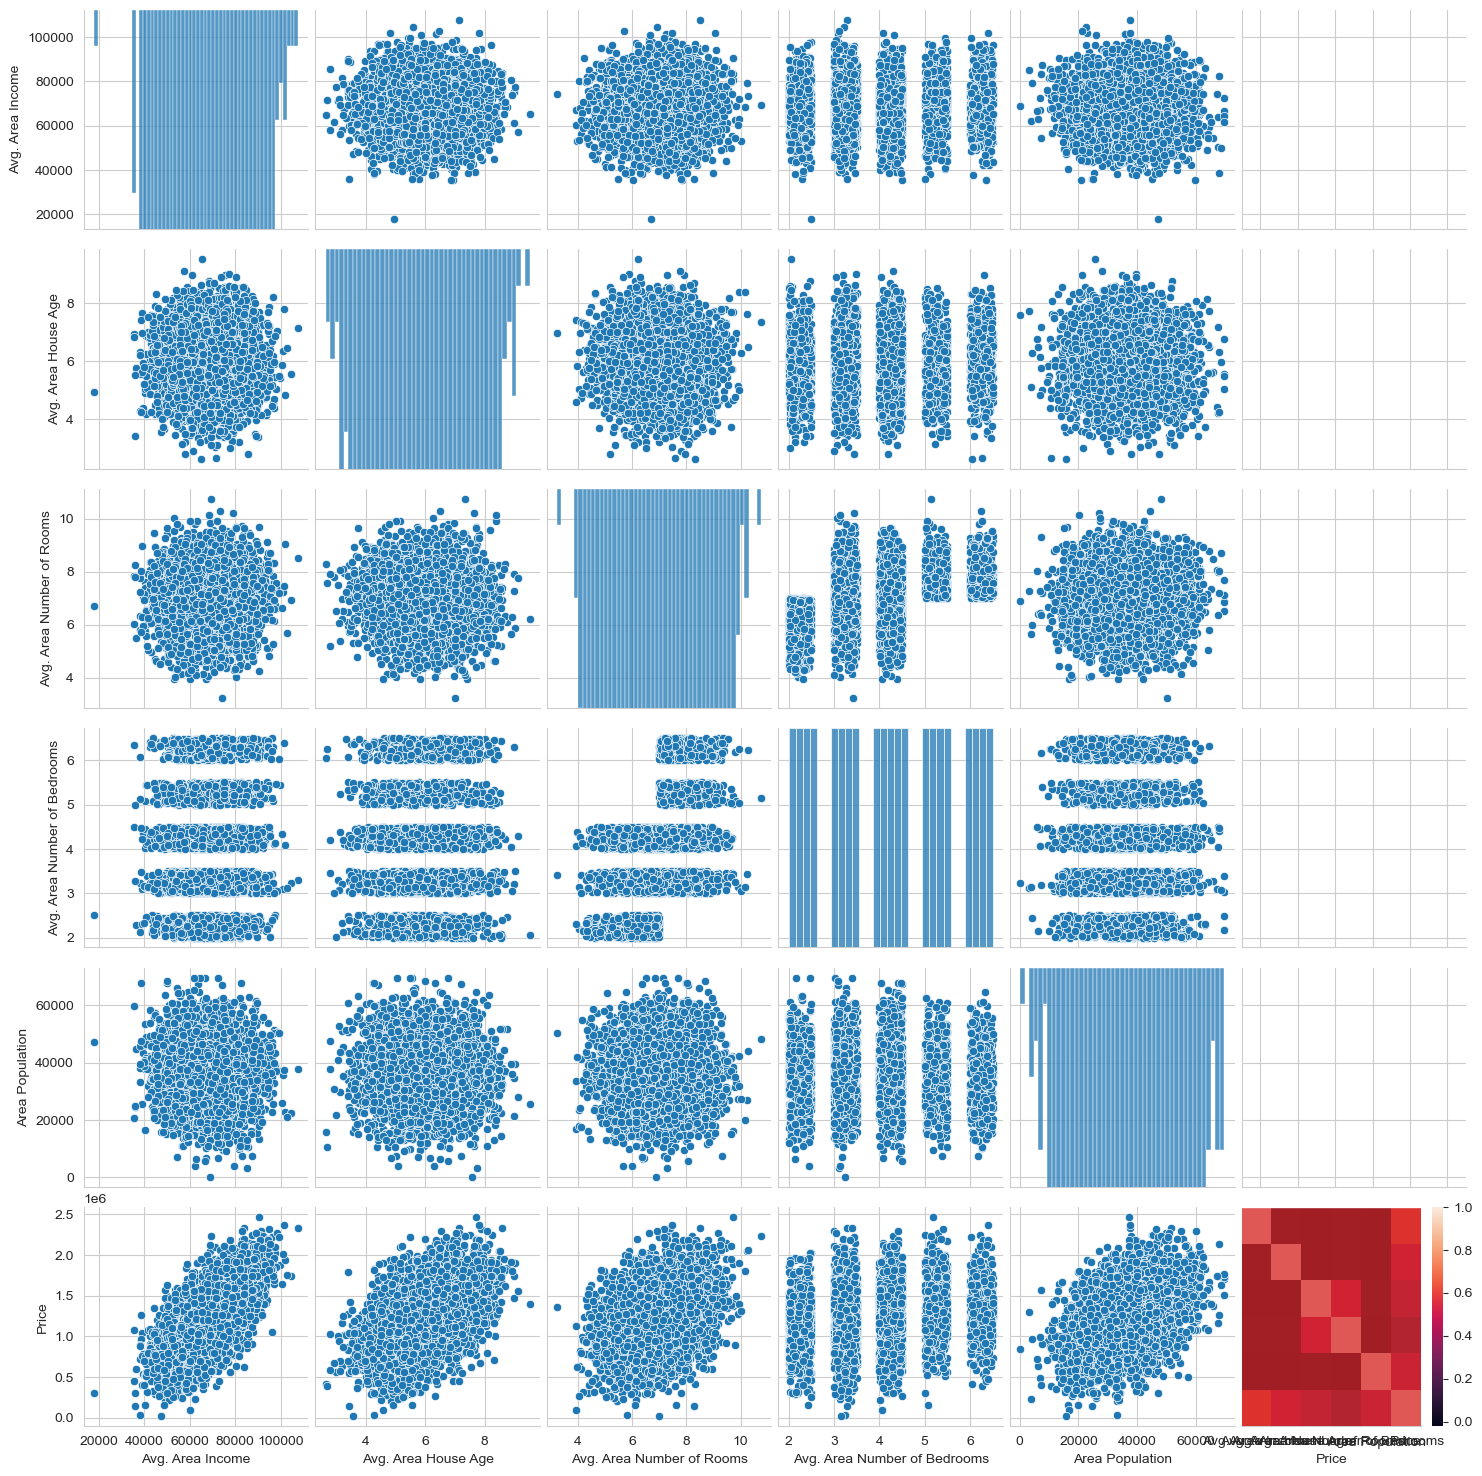

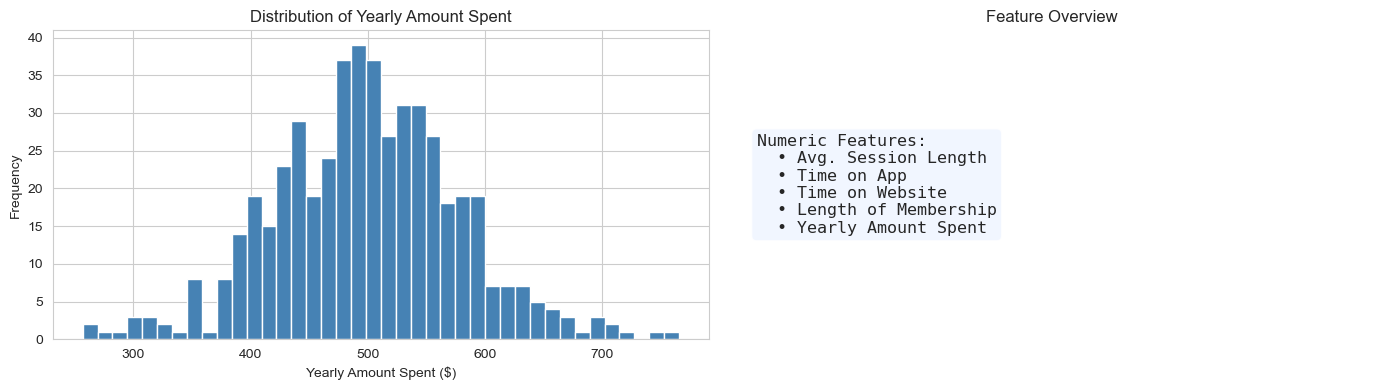

In [35]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Yearly Amount Spent'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Yearly Amount Spent')
axes[0].set_xlabel('Yearly Amount Spent ($)')
axes[0].set_ylabel('Frequency')

# Pairplot of numeric features
numeric_cols = df.select_dtypes(include='float64').columns.tolist()
axes[1].axis('off')
axes[1].text(0.05, 0.5, f'Numeric Features:\n' + '\n'.join([f'  • {c}' for c in numeric_cols]),
             fontsize=12, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#eef4ff', alpha=0.8))
axes[1].set_title('Feature Overview')

plt.tight_layout()
plt.show()

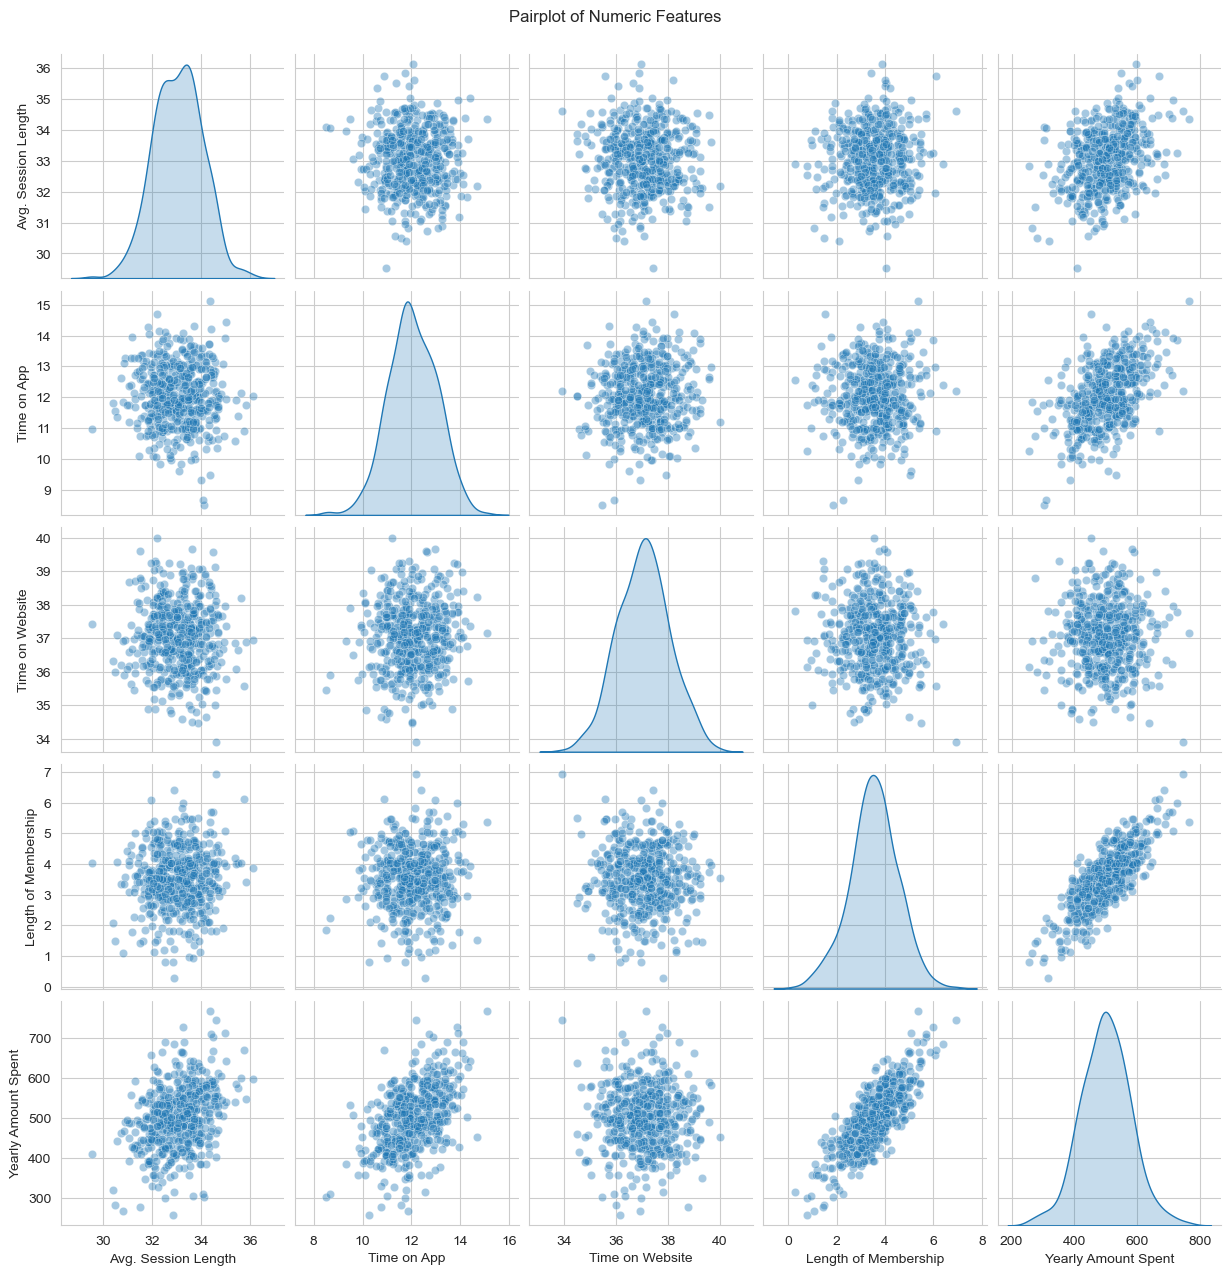

In [36]:
# Pairplot
sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

In [37]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Duplicate rows: 0


In [38]:
# Drop non-predictive text columns
df_clean = df.drop(columns=['Email', 'Address', 'Avatar'])
print('Cleaned shape:', df_clean.shape)
df_clean.head()

Cleaned shape: (500, 5)


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


In [39]:
# Ratio of app engagement vs website
df_clean['App_to_Website_Ratio'] = df_clean['Time on App'] / (df_clean['Time on Website'] + 1e-9)

# Interaction: session depth × app time
df_clean['Engagement_Score'] = df_clean['Avg. Session Length'] * df_clean['Time on App']

print('New features added: App_to_Website_Ratio, Engagement_Score')
df_clean.head()

New features added: App_to_Website_Ratio, Engagement_Score


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,App_to_Website_Ratio,Engagement_Score
0,34.497268,12.655651,39.577668,4.082621,587.951054,0.319767,436.585386
1,31.926272,11.109461,37.268959,2.664034,392.204933,0.298089,354.683665
2,33.000915,11.330278,37.110597,4.104543,487.547505,0.305311,373.909540
3,34.305557,13.717514,36.721283,3.120179,581.852344,0.373558,470.586942
4,33.330673,12.795189,37.536653,4.446308,599.406092,0.340872,426.472239


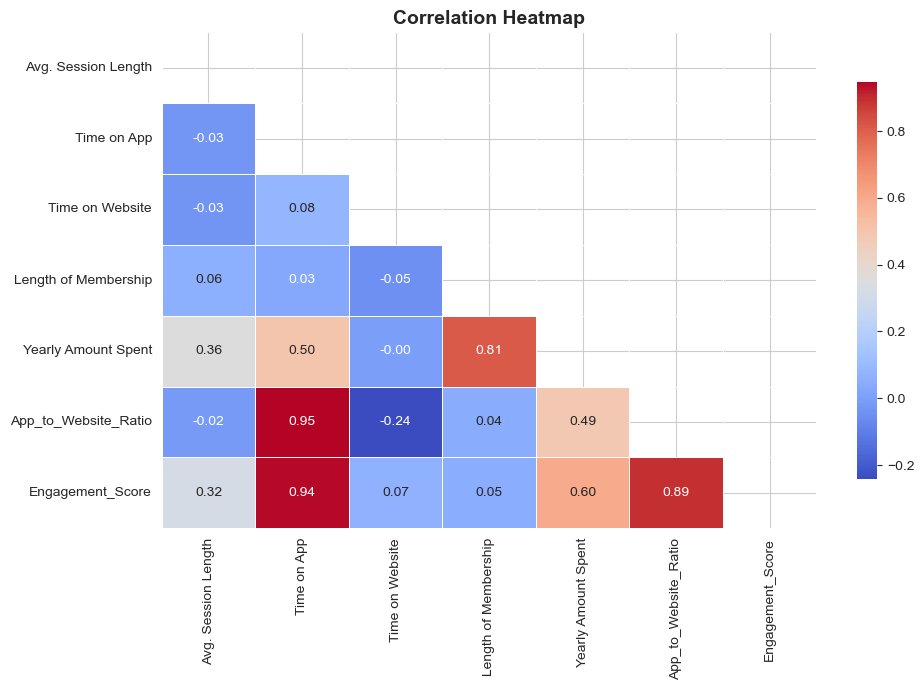

In [40]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
X = df_clean.drop(columns=['Yearly Amount Spent'])
y = df_clean['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size : {X_train.shape}')
print(f'Test  size : {X_test.shape}')

Train size : (350, 6)
Test  size : (150, 6)


In [42]:
model = LinearRegression()
model.fit(X_train_s, y_train)
print('Model trained successfully.')
print(f'Intercept: {model.intercept_:.4f}')

Model trained successfully.
Intercept: 502.3654


In [43]:
y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

metrics = pd.DataFrame({'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
                         'Value' : [round(mae,2), round(mse,2), round(rmse,2), round(r2,4)]})
print(metrics.to_string(index=False))

Metric    Value
   MAE   8.4900
   MSE 105.7000
  RMSE  10.2800
    R²   0.9805


In [44]:
# Feature coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})\
            .sort_values('Coefficient', ascending=False)
coef_df

,Feature,Coefficient
3,Length of Membership,63.361959
4,App_to_Website_Ratio,32.108721
0,Avg. Session Length,22.343835
2,Time on Website,10.749181
5,Engagement_Score,9.253469
1,Time on App,-1.022094


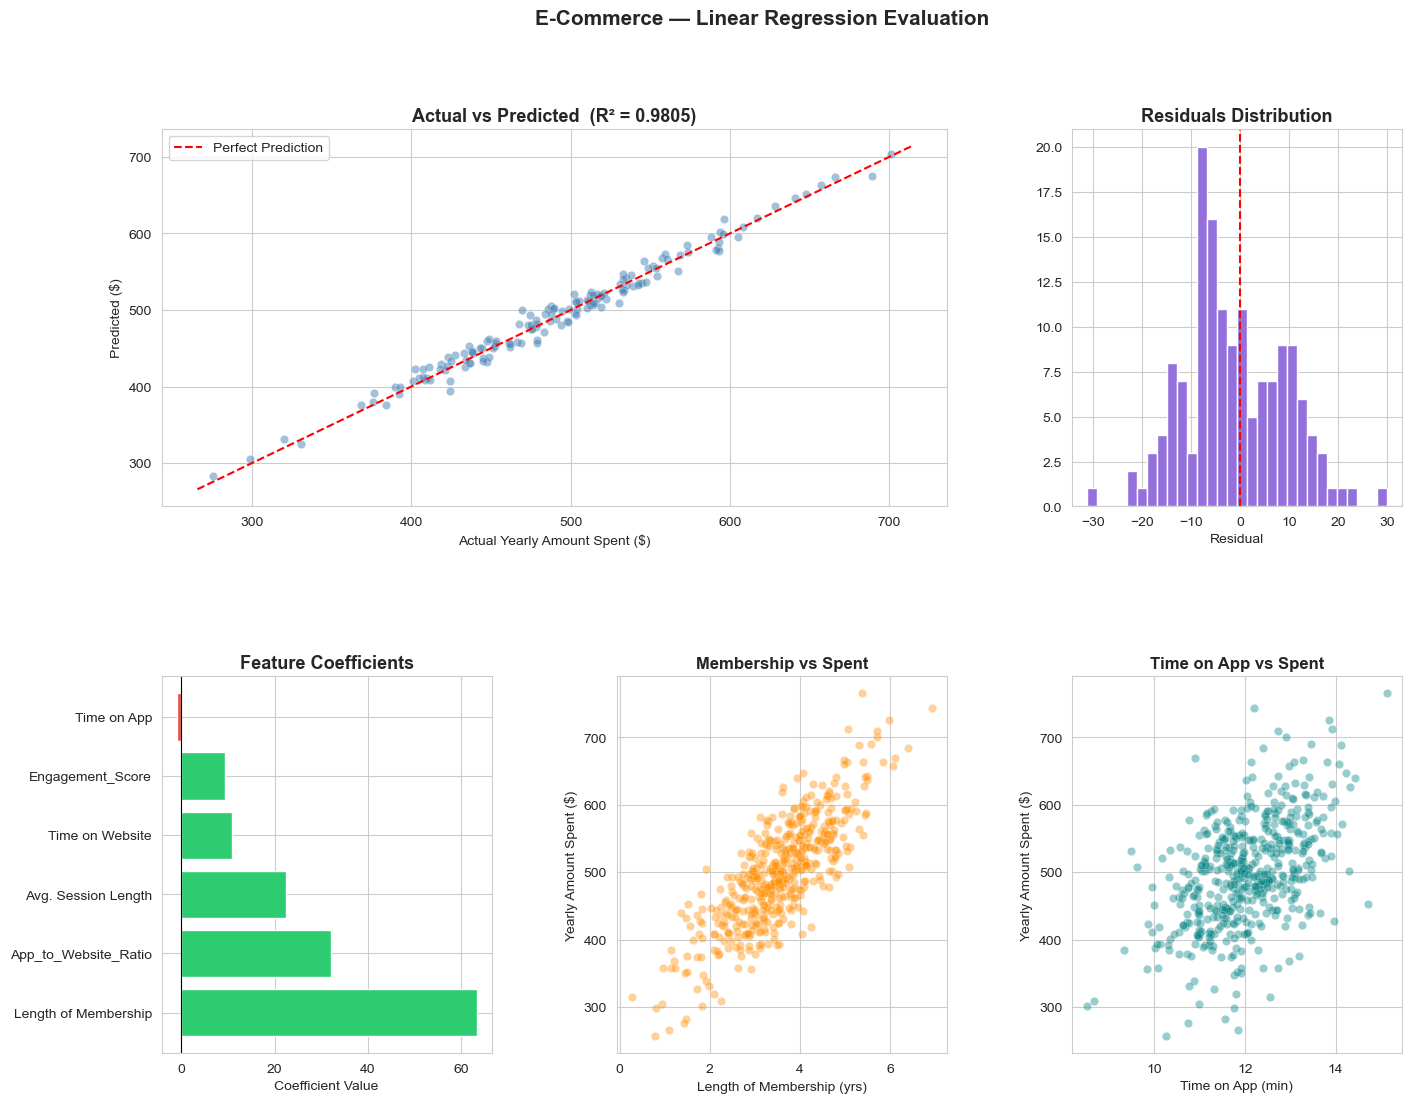

In [45]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# -- Actual vs Predicted
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax1.set_xlabel('Actual Yearly Amount Spent ($)')
ax1.set_ylabel('Predicted ($)')
ax1.set_title(f'Actual vs Predicted  (R² = {r2:.4f})', fontsize=13, fontweight='bold')
ax1.legend()

# -- Residuals Distribution
ax2 = fig.add_subplot(gs[0, 2])
residuals = y_test - y_pred
ax2.hist(residuals, bins=30, color='mediumpurple', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Residuals Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Residual')

# -- Coefficient Bar Chart
ax3 = fig.add_subplot(gs[1, 0])
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax3.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('Feature Coefficients', fontsize=13, fontweight='bold')
ax3.set_xlabel('Coefficient Value')

# -- Membership vs Spent
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(df_clean['Length of Membership'], df_clean['Yearly Amount Spent'],
            alpha=0.4, color='darkorange', edgecolors='white', linewidth=0.3)
ax4.set_xlabel('Length of Membership (yrs)')
ax4.set_ylabel('Yearly Amount Spent ($)')
ax4.set_title('Membership vs Spent', fontsize=12, fontweight='bold')

# -- Time on App vs Spent
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(df_clean['Time on App'], df_clean['Yearly Amount Spent'],
            alpha=0.4, color='teal', edgecolors='white', linewidth=0.3)
ax5.set_xlabel('Time on App (min)')
ax5.set_ylabel('Yearly Amount Spent ($)')
ax5.set_title('Time on App vs Spent', fontsize=12, fontweight='bold')

fig.suptitle('E-Commerce — Linear Regression Evaluation', fontsize=15, fontweight='bold')
plt.show()